# Short IR asymmetry — Monte Carlo

`centrex_asymmetry`'s Monte Carlo method with short-IR parameters, and with the Ramsey
step replaced by an actual integration through Emma's simulated RF field.

## What is reused and what is new

| | source |
|---|---|
| beam sampling, spin projection, arrival kinematics | `centrex_beam.beam`, `.projection` |
| three-switch schedule, bin pooling, parity estimators, block fit | `centrex_beam.switching` |
| LIF photon cycling (explicit, per 5 µs window) | `centrex_beam.photon_cycling`, wrapped by `short_ir.fluorescence` |
| **population transfer through the real RF field** | **`short_ir.ramsey` (new)** |
| **fast binned shot sampler** | **`short_ir.fast_shot` (new)** |

The only physics replaced is `ramsey_probabilities`, which assumes two square pulses
separated by field-free precession:

$$P_1(v)=\sin^2\!\Big(\frac{\Omega L_p}{v}\Big)\cos^2\!\Big(\frac{\pi}{4}+\frac{\phi}{2}
+\frac{\pi\,\Delta f\,L_R}{v}\Big)$$

The short-IR coils are not that: their fields overlap (peaks 0.394 m apart, both inside
the E-field plateau), carry spatial sign structure, and sit where the fringe fields move
$\nu_{je}$ by up to 1.3 kHz. So $P(v)$ comes from integrating the two-level Schrödinger
equation through the measured field.

## Scope

Main pair only (no 8-level manifold). Measured B field, no drift:
$B_\parallel$ = 0.45 mG with the transverse contribution folded in as +0.0115 Hz.
Emma's `FIELD_SCALE = 0.365` and coil-2 phase offset π/2 unchanged. Flight length 5.2 m.
Readout: explicit LIF photon cycling, ported from the main-IR production path
(`run_full_16block_fluorescence.py` + `apply_saved_fluorescence.py`). Injected
$f_{\rm CP}$ = 0.1 Hz.

## The fast method

A molecule's fate after the RF region depends only on its velocity, and $P(v)$ is smooth:

1. **Vectorize the propagator over velocity.** At each $z$ step the rotation generator is
   identical for every molecule; only $dt=dz/v$ differs. 1500 velocities × 4000 steps
   ≈ 0.1 s.
2. **Tabulate $P(v)$, then interpolate** — a drop-in for `ramsey_probabilities`.
3. **Sample counts per bin, not per molecule.** Spin and start time are independent given
   $v$, so the joint count distribution factorizes into a multinomial over velocity bins,
   a binomial for the spin, and a multinomial over arrival bins.

**46 ms versus 4.4 s for a 2×10⁷-molecule shot, and nearly independent of $N$.**

## Two binnings, deliberately different

| | width | purpose |
|---|---|---|
| acquisition | 10 µs | what the experiment records; makes a clean TOF trace |
| **analysis** | **1 ms** | what the bin-first extraction runs at |

1 ms matches the time-of-flight velocity resolution; finer bins add no velocity
information, only noise per bin.

Environment: the existing `CeNTREX_state_cleanup_new` conda env suffices —
`centrex_beam` is pure numpy/pandas/scipy.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path

CENTREX_ASYMMETRY = r"C:/Users/yuanhang.yang/Documents/GitHub/centrex_asymmetry"
HERE = str(Path.cwd())
for p in (CENTREX_ASYMMETRY, HERE):
    if p not in sys.path:
        sys.path.insert(0, p)

import dataclasses
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import centrex_beam as cb
import short_ir as si

CFG = si.ShortIRConfig()
FIELD = si.ShortIRField(CFG)
print(FIELD.summary())

v, sv, sts, L = CFG.mean_velocity, CFG.velocity_spread, CFG.start_time_spread, \
    CFG.flight_length
print(f"\nflight length {L} m -> mean arrival {L/v*1e3:.2f} ms")
print(f"  arrival spread from the velocity spread : {L*sv/v**2*1e3:.3f} ms")
print(f"  start-time spread                       : {sts*1e3:.3f} ms")
print(f"  -> arrival time is dominated by velocity, which is what makes")
print(f"     time-of-flight binning sort molecules by velocity at all.")
print(f"  TOF velocity resolution = sigma_ts*v^2/L  : {sts*v**2/L:.2f} m/s "
      f"of a {sv:.0f} m/s spread, i.e. ~{sts*1e3:.2f} ms of arrival time")


domain        z = 0.010 .. 1.990 m (1.980 m, 4000 steps)
coil peaks    1.197 and 0.803 m -> separation 0.394 m
B peak        0.2976 G (field_scale = 0.365)
E             0.0001 .. 29.7587 kV/cm, plateau 29.7194
|M|           1358.50 .. 1367.38 Hz/G
nu_je         119521.6 .. 120851.7 Hz
nu_rf         119522.8112 Hz
E field inside the lookup range

flight length 5.2 m -> mean arrival 28.26 ms
  arrival spread from the velocity spread : 2.457 ms
  start-time spread                       : 1.000 ms
  -> arrival time is dominated by velocity, which is what makes
     time-of-flight binning sort molecules by velocity at all.
  TOF velocity resolution = sigma_ts*v^2/L  : 6.51 m/s of a 16 m/s spread, i.e. ~1.00 ms of arrival time


## Operating phase and photon budget

The readout is the channel asymmetry $A = 1-2P_e$, with the RF phase set so $A=0$ at the
nominal velocity — the fringe zero crossing, where the phase slope is largest and a gain
drift cannot leak into the signal. Solved once and then held fixed.

In [2]:
OP_PHASE = si.find_operating_phase(FIELD, CFG)
TABLE = si.RamseyTable(FIELD, CFG, phase_2=OP_PHASE)
i0 = int(np.argmin(np.abs(TABLE.v_grid - CFG.mean_velocity)))
F, MOM = si.photon_excess_noise_factor(CFG)

print(f"operating phase = {OP_PHASE:+.6f} rad = {OP_PHASE/np.pi:+.6f} pi "
      f"(Emma's pi/2 = {np.pi/2:.6f})")
print(f"P_e at v = {CFG.mean_velocity} m/s : {TABLE.p_excited[i0]:.6f}   (0.5 expected)")
print(f"\nphoton budget: {MOM['mean_emitted']:.3f} emitted, "
      f"{MOM['mean_detected']:.4f} detected per molecule -> F = {F:.4f}")
print(f"so sigma_A = F/sqrt(N), not 1/sqrt(N)")


operating phase = +1.683123 rad = +0.535755 pi (Emma's pi/2 = 1.570796)
P_e at v = 184.0 m/s : 0.500044   (0.5 expected)

photon budget: 2.074 emitted, 0.1078 detected per molecule -> F = 3.2109
so sigma_A = F/sqrt(N), not 1/sqrt(N)


## $P(v)$ from the real field

The analytic model is overlaid for reference. They are not expected to agree in detail —
that is the point of doing this.

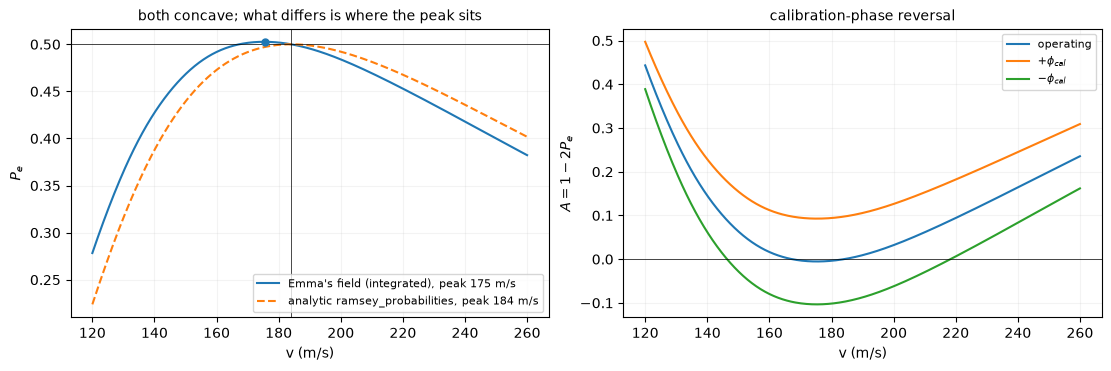

No fringe oscillation across the velocity range: the residual detuning is only
~1 Hz, so the Ramsey phase barely moves with v. The variation is pulse area, 1/v.

Both models give P_e(v) an interior maximum -- the pulse area is optimal at one
velocity and falls off either side. What differs is WHERE:
  analytic   peaks at  183.9 m/s   (hardcoded: Omega*L_p = (pi/2)*v_ref)
  real field peaks at  175.4 m/s   (-4.7% vs the beam mean)

The analytic model therefore sits exactly on its own velocity null and has no
first-order sensitivity; the real field at FIELD_SCALE 0.365 sits on the flank.
Scaling the amplitude by 1.0488 -> 0.383 moves the peak onto the beam
mean, which is the same amplitude the dA/dv scan finds independently.


In [3]:
vv = np.linspace(120.0, 260.0, 400)

# Sign convention: RamseyTable's channel 1 is the state the molecules start in (j), so
# P_e = 1 - TABLE(v). centrex_beam's channel 1 is the opposite -- the TRANSFERRED state --
# because sin^2(Omega L_p / v) vanishes with the drive. So ramsey_probabilities IS P_e and
# must NOT be complemented. (Earlier this cell wrote 1 - ramsey_probabilities, which plots
# P_j against P_e and makes the two models look qualitatively different when they are not.)
p_real = 1.0 - TABLE(vv)
p_ana = cb.ramsey_probabilities(
    vv, 0.0, 0.0, pulse_length=0.025,
    precession_length=FIELD.separation, reference_velocity=CFG.mean_velocity)

v_peak_real = vv[p_real.argmax()]
v_peak_ana = vv[p_ana.argmax()]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
axes[0].plot(vv, p_real, label=f"Emma's field (integrated), peak {v_peak_real:.0f} m/s")
axes[0].plot(vv, p_ana, "--", label=f"analytic ramsey_probabilities, peak {v_peak_ana:.0f} m/s")
axes[0].axhline(0.5, color="k", lw=0.5); axes[0].axvline(CFG.mean_velocity, color="k", lw=0.5)
axes[0].plot([v_peak_real], [p_real.max()], "o", ms=5, color="C0")
axes[0].set_xlabel("v (m/s)"); axes[0].set_ylabel(r"$P_e$")
axes[0].set_title("both concave; what differs is where the peak sits", fontsize=10)
axes[0].legend(fontsize=8); axes[0].grid(alpha=.15)

for dphi, lbl in [(0.0, "operating"), (+np.pi/32, r"$+\phi_{cal}$"),
                  (-np.pi/32, r"$-\phi_{cal}$")]:
    pe = si.propagate_velocities(FIELD, vv, phase_2=OP_PHASE + dphi,
                                 b_par_G=CFG.b_par_G, dnu_dB_par=CFG.dnu_dB_par,
                                 dnu_transverse_Hz=CFG.dnu_transverse_Hz)
    axes[1].plot(vv, 1 - 2*pe, label=lbl)
axes[1].axhline(0.0, color="k", lw=0.5)
axes[1].set_xlabel("v (m/s)"); axes[1].set_ylabel("$A = 1-2P_e$")
axes[1].set_title("calibration-phase reversal", fontsize=10)
axes[1].legend(fontsize=8); axes[1].grid(alpha=.15)
plt.show()

print("No fringe oscillation across the velocity range: the residual detuning is only")
print("~1 Hz, so the Ramsey phase barely moves with v. The variation is pulse area, 1/v.")
print()
print(f"Both models give P_e(v) an interior maximum -- the pulse area is optimal at one")
print(f"velocity and falls off either side. What differs is WHERE:")
print(f"  analytic   peaks at {v_peak_ana:6.1f} m/s   (hardcoded: Omega*L_p = (pi/2)*v_ref)")
print(f"  real field peaks at {v_peak_real:6.1f} m/s   "
      f"({(v_peak_real/CFG.mean_velocity-1)*100:+.1f}% vs the beam mean)")
print()
print("The analytic model therefore sits exactly on its own velocity null and has no")
print("first-order sensitivity; the real field at FIELD_SCALE 0.365 sits on the flank.")
print(f"Scaling the amplitude by {CFG.mean_velocity/v_peak_real:.4f} -> "
      f"{CFG.field_scale*CFG.mean_velocity/v_peak_real:.3f} moves the peak onto the beam")
print("mean, which is the same amplitude the dA/dv scan finds independently.")


## Sampler validation

The fast binned sampler against the per-molecule reference. The deterministic expected
asymmetry (no sampling) must agree to the velocity-bin-averaging accuracy; the realized
values must agree within shot noise.

In [4]:
import time

N_TEST = int(2e7)
res = {}
for name, fn in [("binned", si.simulate_shot_binned),
                 ("streaming", si.simulate_shot_streaming)]:
    t0 = time.perf_counter()
    res[name] = fn(CFG, TABLE, N_TEST, rng=np.random.default_rng(1), shot_mean=184.0)
    res[name]["elapsed_s"] = time.perf_counter() - t0

print(f"{'sampler':>10} {'A':>12} {'sigma_A':>11} {'E[A]':>13} {'time':>10}")
for name, r in res.items():
    w = r["whole_shot"]
    print(f"{name:>10} {w['asymmetry']:>+12.6f} {w['sigma_asymmetry']:>11.3e} "
          f"{2*r['expected_N_1']/N_TEST-1:>+13.8f} {r['elapsed_s']*1e3:>9.0f} ms")
ea = 2*res["binned"]["expected_N_1"]/N_TEST - 1
eb = 2*res["streaming"]["expected_N_1"]/N_TEST - 1
print(f"\ndeterministic E[A] difference = {ea-eb:+.2e}  "
      f"(shot noise {res['binned']['whole_shot']['sigma_asymmetry']:.2e})")
print(f"speedup = {res['streaming']['elapsed_s']/res['binned']['elapsed_s']:.0f}x")


   sampler            A     sigma_A          E[A]       time
    binned    +0.016534   2.235e-04   +0.01621885        63 ms
 streaming    +0.016243   2.235e-04   +0.01622464      3848 ms

deterministic E[A] difference = -5.79e-06  (shot noise 2.23e-04)
speedup = 61x


## Three-switch run

Schedule, pooling and estimators are `centrex_beam.switching`, unmodified. The CP reversal
enters as a frequency shift added to $\nu_{je}$, so the propagator produces its
velocity-dependent phase automatically rather than assuming $2\pi f_{\rm CP}L/v$.

$f_{\rm CP}$ = 0.1 Hz, deep in the linear regime ($A_c/A_d$ = 0.2). A physical EDM signal
is ~$10^{-7}$ Hz. Below ~0.1 Hz the error bar is the additive noise floor and does not
depend on $f_{\rm CP}$ (measured: $f_{\rm CP}$ = 0 and $3\times10^{-7}$ Hz agree to 0.1%),
so 0.1 Hz reproduces the physical error bar while staying visible.

In [5]:
T_EFF_GUESS = 2.426e-3

# Injected CP-odd frequency. 0.1 Hz gives A_c/A_d = 0.2, deep in the linear regime.
# Below ~0.1 Hz the error bar is the additive floor (LIF readout + shot velocity scatter
# + spin projection) and does not depend on f_CP, so this reproduces the error bar of a
# physical EDM signal (~1e-7 Hz). Above ~0.4 Hz a multiplicative term f_CP * dA_d/A_d
# takes over: the pi/128 = 1.61 Hz used earlier gives calibration-sized error bars.
F_CP = 0.01
# F_CP = (np.pi/128) / (2*np.pi*T_EFF_GUESS)   # 1.61 Hz, calibration-sized
# F_CP = 0                                      # null test
N_BLOCKS, N_MOL = 32, int(1e10)
print(f"injected f_CP = {F_CP:.6f} Hz   "
      f"(f_CP / df_sw = {F_CP/si.DETUNING_SWITCH_HZ:.5f})")

OUT = si.run_short_ir_blocks(
    FIELD, CFG, n_blocks=N_BLOCKS, n_molecules=N_MOL,
    detuning_hz=si.DETUNING_SWITCH_HZ,
    calibration_phase_rad=si.CALIBRATION_PHASE_RAD,
    cp_frequency_hz=F_CP, operating_phase_rad=OP_PHASE, seed=11)
SUMMARY, STATE_BINS = OUT["summary"], OUT["state_bins"]
STATE_ORDER = (SUMMARY.groupby("switch_label", sort=True)
               .size().index.tolist())
print(f"\n{len(SUMMARY)} shots, {len(STATE_BINS)} pooled state-bins")


injected f_CP = 0.010000 Hz   (f_CP / df_sw = 0.02000)
building P(v) tables for 256 shots (8 distinct states)
  [1/8] phase=+0.098175 rad  detuning=+0.500 Hz  cp=+1
  [2/8] phase=-0.098175 rad  detuning=-0.500 Hz  cp=-1
  [3/8] phase=-0.098175 rad  detuning=+0.500 Hz  cp=+1
  [4/8] phase=+0.098175 rad  detuning=-0.500 Hz  cp=+1
  [5/8] phase=+0.098175 rad  detuning=+0.500 Hz  cp=-1
  [6/8] phase=-0.098175 rad  detuning=-0.500 Hz  cp=+1
  [7/8] phase=+0.098175 rad  detuning=-0.500 Hz  cp=-1
  [8/8] phase=-0.098175 rad  detuning=+0.500 Hz  cp=-1

tables 1.39 s, 256 shots 19.56 s (76.4 ms/shot, method=binned)

256 shots, 47012 pooled state-bins


## What the data look like

The same three figures `centrex_asymmetry_study.ipynb` produces, so the short-IR output
can be read the same way.

**Per-shot asymmetry.** Eight switch states interleaved in randomized balanced blocks.
The spread within a colour is shot noise plus shot-to-shot velocity scatter; the
separation between colours is the switch response.

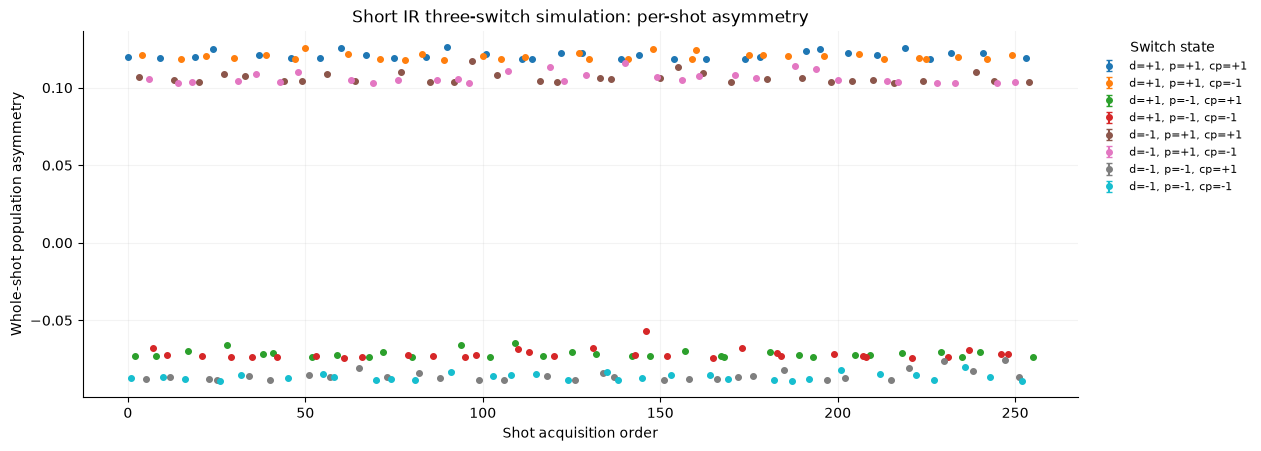

In [6]:
fig, ax = plt.subplots(figsize=(12.5, 4.4), constrained_layout=True)
colors = plt.cm.tab10(np.linspace(0, 0.9, 8))
for color, label in zip(colors, STATE_ORDER):
    state = SUMMARY[SUMMARY["switch_label"] == label].sort_values("acquisition_order")
    ax.errorbar(state["acquisition_order"], state["asymmetry"],
                yerr=state["sigma_asymmetry"], fmt="o", ms=4, capsize=2,
                color=color, label=label)
ax.set_xlabel("Shot acquisition order")
ax.set_ylabel("Whole-shot population asymmetry")
ax.set_title("Short IR three-switch simulation: per-shot asymmetry")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=.15)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False,
          title="Switch state")
plt.show()


**Switching structure.** In the style of ACME II's Extended Data Fig. 1 (Andreev et al.,
Nature 562, 355 (2018)). ACME nests its switches by speed: within a ~45 s *block* the
molecular state $\tilde N$ flips every 0.5 s, the E field $\tilde E$ every ~2 s, the readout
polarisation dither $\tilde\theta$ every 10 s and the magnetic field $\tilde B$ once per block;
slower *superblock* switches ($\tilde P$ random, $\tilde L$ every 4 blocks, $\tilde R$ every 8)
change only between blocks (P. W. Hess, Harvard PhD thesis 2014, §5.1).

The roles map onto the three switches here:

| here | role | ACME analogue |
|---|---|---|
| $\tilde c$ | CP-odd reversal (the E reversal; also sets the sign of $B_{\rm mot}$) | $\tilde N\tilde E$ |
| $\tilde d$ | known frequency offset ±0.5 Hz, the ruler that converts asymmetry to Hz | $\tilde B$ (known Zeeman precession) |
| $\tilde p$ | calibration phase ±π/32, measures the fringe slope (contrast) | $\tilde\theta$ |

**Difference in ordering.** This model does not nest the switches: each 8-shot block contains
every $(d,p,c)$ combination once, in a random order. Panel (a) is the schedule this run
actually used; panel (b) is the nested ACME-style ordering of the same three switches, for
comparison only. Every switch state is taken to last the same time `SHOT_DT`.


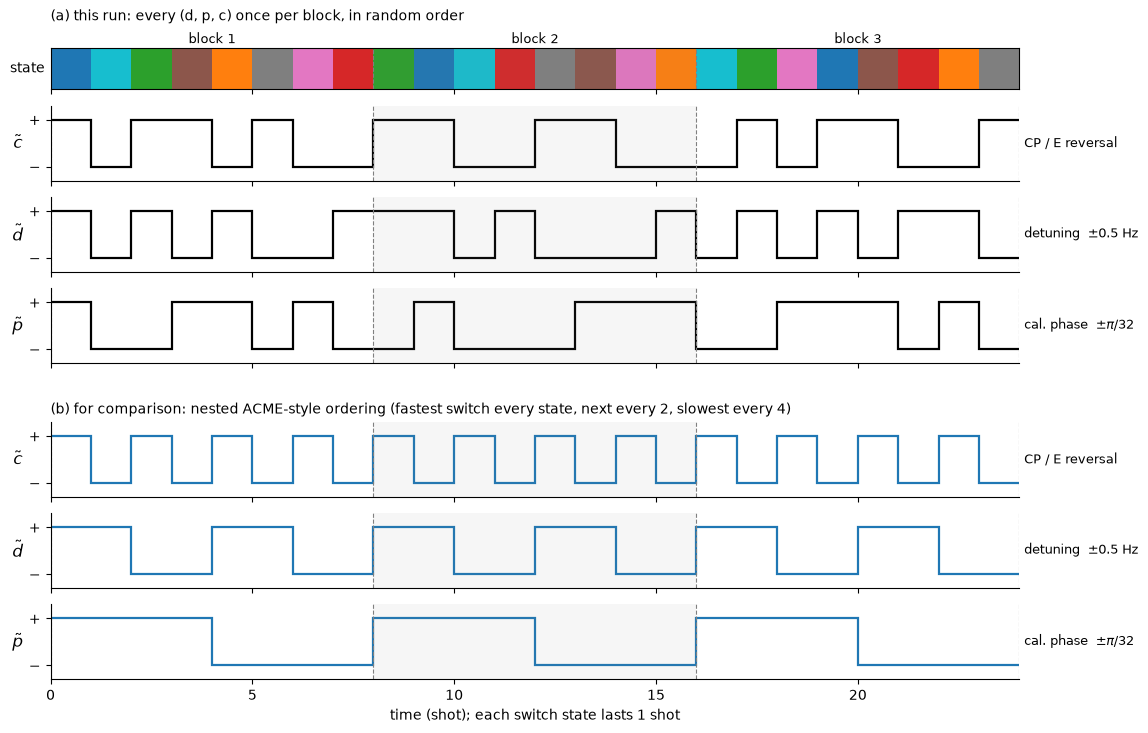

mean time a switch stays in one state, whole run (256 shots, 32 blocks, block = 8 shot):
  CP / E reversal               1.63 shot   (nested ordering: 1 shot)
  detuning +-0.5 Hz             1.77 shot   (nested ordering: 2 shot)
  calibration phase +-pi/32     1.91 shot   (nested ordering: 4 shot)

With random ordering all three switches flip on the same short timescale, so a slow
drift is not aliased preferentially onto any one of them. ACME's nesting is set by how
fast each switch can be actuated (B needs a degauss cycle, so it is slowest), with the
switches the EDM is odd under (N, E) fastest so they reject the widest band of drifts.


In [7]:
SHOT_DT = 1.0          # duration of one switch state (one shot); arbitrary units
TIME_UNIT = "shot"     # e.g. set SHOT_DT = 0.02, TIME_UNIT = "s" for 50 Hz shots
N_SHOW_BLOCKS = 3      # blocks drawn

SWITCHES = [   # column, axis label, plot description, plain-text description
    ("cp_state", r"$\tilde c$", "CP / E reversal", "CP / E reversal"),
    ("detuning_state", r"$\tilde d$", f"detuning  $\\pm${si.DETUNING_SWITCH_HZ:g} Hz",
     f"detuning +-{si.DETUNING_SWITCH_HZ:g} Hz"),
    ("phase_state", r"$\tilde p$", r"cal. phase  $\pm\pi/32$", "calibration phase +-pi/32"),
]
STATES_PER_BLOCK = 8
color_of = dict(zip(STATE_ORDER, colors))          # same colours as the per-shot plot

sched = SUMMARY.sort_values("acquisition_order")
shown = sched[sched["block"] < N_SHOW_BLOCKS]
n_show = len(shown)
t0 = shown["acquisition_order"].to_numpy() * SHOT_DT
edges = np.append(t0, t0[-1] + SHOT_DT)


def square_wave(ax, values, name, desc, color="k"):
    ax.stairs(values, edges, baseline=None, color=color, lw=1.6)
    ax.set_ylim(-1.6, 1.6); ax.set_yticks([-1, 1]); ax.set_yticklabels(["−", "+"])
    ax.set_ylabel(name, rotation=0, ha="right", va="center", fontsize=12)
    ax.text(1.005, 0.5, desc, transform=ax.transAxes, va="center", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)


def block_marks(ax, label=False):
    for b in range(N_SHOW_BLOCKS + 1):
        ax.axvline(b*STATES_PER_BLOCK*SHOT_DT, color="grey", ls="--", lw=0.8)
    for b in range(N_SHOW_BLOCKS):
        if b % 2:
            ax.axvspan(b*STATES_PER_BLOCK*SHOT_DT, (b + 1)*STATES_PER_BLOCK*SHOT_DT,
                       color="grey", alpha=0.07, lw=0)
        if label:
            ax.text((b + 0.5)*STATES_PER_BLOCK*SHOT_DT, 1.12, f"block {b + 1}",
                    transform=ax.get_xaxis_transform(), ha="center", fontsize=9)


n_rows = 1 + 2*len(SWITCHES)
fig, axes = plt.subplots(
    n_rows + 1, 1, figsize=(12.5, 8.2), sharex=True,
    gridspec_kw=dict(height_ratios=[0.55] + [1]*len(SWITCHES) + [0.35]
                     + [1]*len(SWITCHES), hspace=0.25))
strip, ax_run = axes[0], axes[1:1 + len(SWITCHES)]
gap, ax_nest = axes[1 + len(SWITCHES)], axes[2 + len(SWITCHES):]

# (a) the schedule actually used
for (_, row), left in zip(shown.iterrows(), t0):
    strip.axvspan(left, left + SHOT_DT, color=color_of[row["switch_label"]], lw=0)
strip.set_yticks([]); strip.set_ylim(0, 1)
strip.set_ylabel("state", rotation=0, ha="right", va="center", fontsize=10)
strip.set_title("(a) this run: every (d, p, c) once per block, in random order",
                fontsize=10, loc="left", pad=20)
block_marks(strip, label=True)
for ax, (col, name, desc, _) in zip(ax_run, SWITCHES):
    square_wave(ax, shown[col].to_numpy(), name, desc)
    block_marks(ax)

# (b) nested ACME-style ordering of the same three switches, for comparison
gap.axis("off")
k = np.arange(n_show)
nested = {"cp_state": (-1)**k, "detuning_state": (-1)**(k//2), "phase_state": (-1)**(k//4)}
ax_nest[0].set_title("(b) for comparison: nested ACME-style ordering "
                     "(fastest switch every state, next every 2, slowest every 4)",
                     fontsize=10, loc="left")
for ax, (col, name, desc, _) in zip(ax_nest, SWITCHES):
    square_wave(ax, nested[col], name, desc, color="#1f77b4")
    block_marks(ax)
ax_nest[-1].set_xlabel(f"time ({TIME_UNIT}); each switch state lasts {SHOT_DT:g} {TIME_UNIT}")
ax_nest[-1].set_xlim(edges[0], edges[-1])
plt.show()

# Switch timescales over the whole run, the way ACME quotes theirs.
print(f"mean time a switch stays in one state, whole run ({len(sched)} shots, "
      f"{sched['block'].nunique()} blocks, block = {STATES_PER_BLOCK*SHOT_DT:g} {TIME_UNIT}):")
for col, name, _, desc in SWITCHES:
    s = sched[col].to_numpy()
    flips = np.count_nonzero(np.diff(s))
    nested_dwell = {"cp_state": 1, "detuning_state": 2, "phase_state": 4}[col]
    print(f"  {desc:<28} {len(s)/(flips + 1)*SHOT_DT:5.2f} {TIME_UNIT}   "
          f"(nested ordering: {nested_dwell*SHOT_DT:g} {TIME_UNIT})")
print("\nWith random ordering all three switches flip on the same short timescale, so a slow")
print("drift is not aliased preferentially onto any one of them. ACME's nesting is set by how")
print("fast each switch can be actuated (B needs a degauss cycle, so it is slowest), with the")
print("switches the EDM is odd under (N, E) fastest so they reject the widest band of drifts.")


**Time-resolved asymmetry, one panel per switch state.** Counts are pooled across
shots with the same $(d,p,c)$ before forming the asymmetry, matched on absolute 10 µs bin
index so that different shots' arrival tails line up. The black curve is the conditional
mean, i.e. what the known probabilities predict — the simulated trace should scatter
around it by shot noise only.

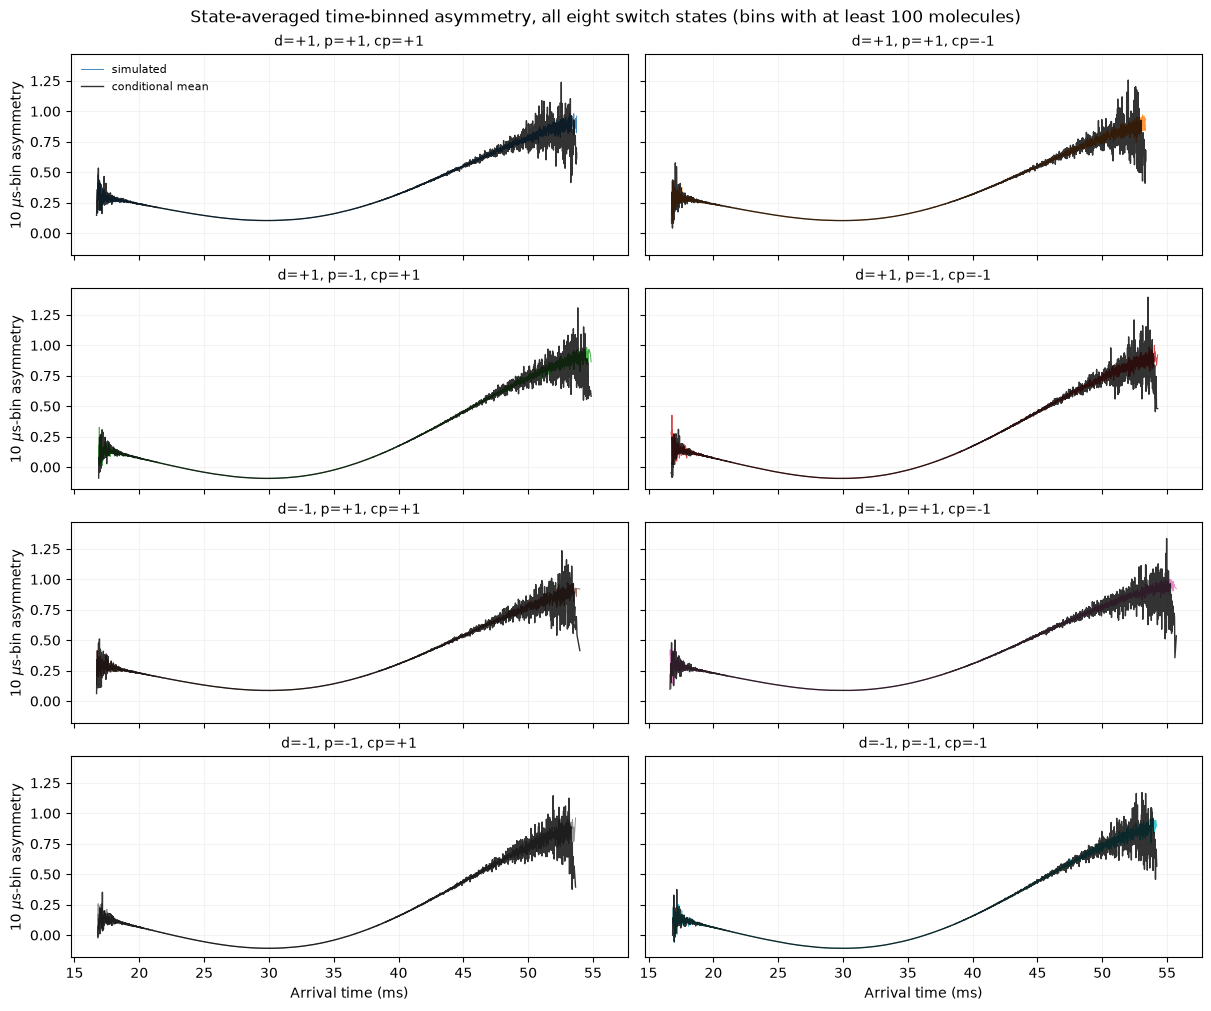

The velocity dependence of the switch response shows up as arrival-time
structure: each bin corresponds to a different velocity, hence a different
interaction time and pulse area. That is what the bin-first extraction exploits.


In [8]:
PLOT_MIN_COUNT = 100          # display threshold only; all bins stay in STATE_BINS
fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, color, label in zip(axes.flat, colors, STATE_ORDER):
    st = STATE_BINS[(STATE_BINS["switch_label"] == label)
                    & (STATE_BINS["n"] >= PLOT_MIN_COUNT)].sort_values("time_center_s")
    ax.plot(1e3*st["time_center_s"], st["asymmetry"], color=color, lw=0.7,
            alpha=0.85, label="simulated")
    ax.plot(1e3*st["time_center_s"], st["expected_asymmetry"], color="black",
            lw=1.0, alpha=0.8, label="conditional mean")
    ax.set_title(label, fontsize=10); ax.grid(alpha=0.15)
for ax in axes[-1, :]:
    ax.set_xlabel("Arrival time (ms)")
for ax in axes[:, 0]:
    ax.set_ylabel(r"10 $\mu$s-bin asymmetry")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle(f"State-averaged time-binned asymmetry, all eight switch states "
             f"(bins with at least {PLOT_MIN_COUNT} molecules)", fontsize=12)
plt.show()

print("The velocity dependence of the switch response shows up as arrival-time")
print("structure: each bin corresponds to a different velocity, hence a different")
print("interaction time and pulse area. That is what the bin-first extraction exploits.")


## Pooled extraction, and why it is not enough

`linear_switch_analysis` returns two things: an `aggregate` over the whole retained
window, and `time_bins`, one estimate per arrival bin. The aggregate pools all velocities
into one number, so its linearization assumes a single interaction time — which is exactly
what shot-to-shot velocity scatter breaks.

The four-panel figure below is the per-arrival-bin extraction. Contrast and interaction
time both vary across arrival time because arrival time sorts by velocity. **The bottom
panel is the per-bin ratio $f_{\rm CP}=\Delta f_{\rm sw}A_c/A_d$, which blows up wherever
$A_d$ crosses zero** — that is why the next section fits a single slope instead of taking
per-bin ratios.

Retained 98.014% of molecules, 22.77 to 35.93 ms



,quantity,estimate,conditional sigma,injected
0,contrast,0.981334,0.000006,NaN
1,interaction time (ms),2.343703,0.000204,NaN
2,CP-odd phase (mrad),0.209321,0.000640,0.147259
3,CP-odd frequency (Hz),0.014214,0.000043,0.010000


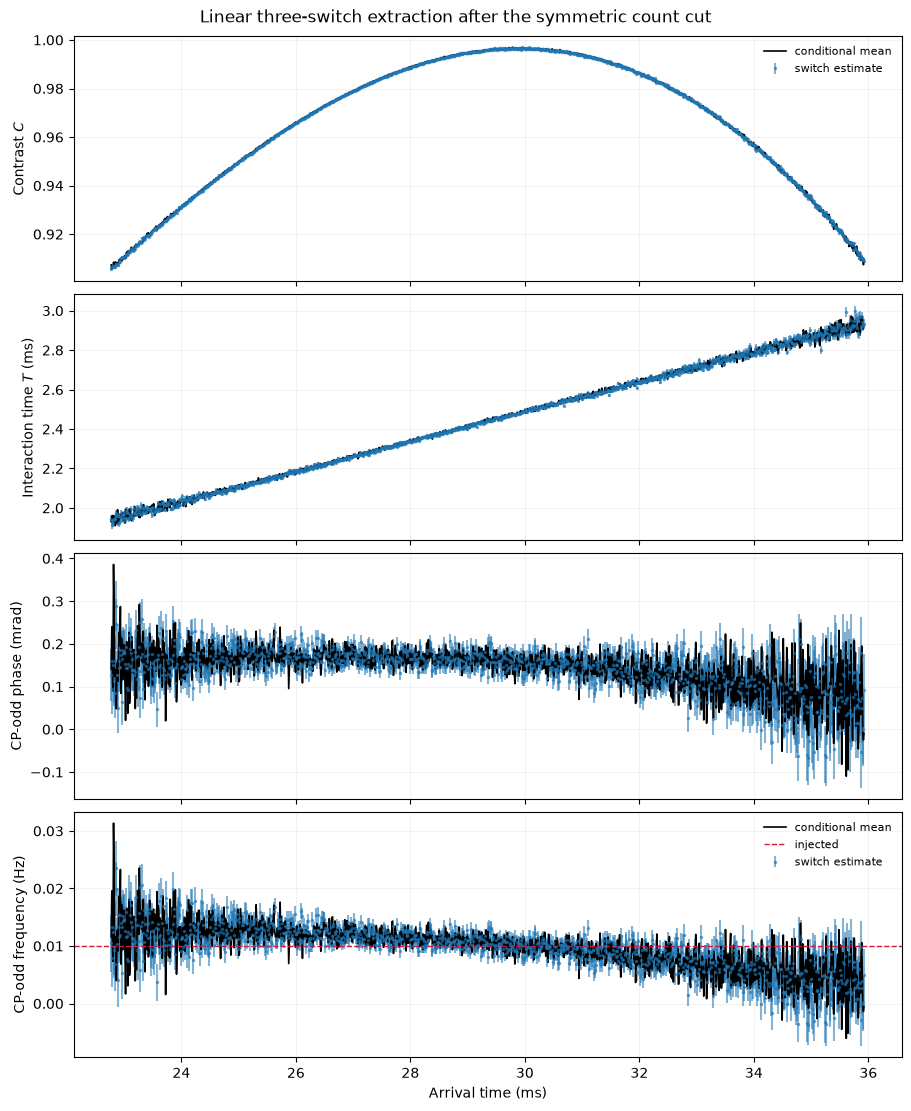

In [9]:
LIN = si.extract(STATE_BINS, calibration_phase_rad=si.CALIBRATION_PHASE_RAD,
                 detuning_hz=si.DETUNING_SWITCH_HZ)
AGG, TB = LIN["aggregate"], LIN["time_bins"]

print(f"Retained {AGG.retained_fraction:.3%} of molecules, "
      f"{1e3*AGG.time_start_s:.2f} to {1e3*AGG.time_end_s:.2f} ms\n")
display(pd.DataFrame({
    "quantity": ["contrast", "interaction time (ms)", "CP-odd phase (mrad)",
                 "CP-odd frequency (Hz)"],
    "estimate": [AGG.contrast, 1e3*AGG.interaction_time_s, 1e3*AGG.cp_phase_rad,
                 AGG.cp_frequency_hz],
    "conditional sigma": [AGG.sigma_contrast, 1e3*AGG.sigma_interaction_time_s,
                          1e3*AGG.sigma_cp_phase_rad, AGG.sigma_cp_frequency_hz],
    "injected": [np.nan, np.nan, 1e3*2*np.pi*F_CP*AGG.interaction_time_s, F_CP],
}))

fig, axes = plt.subplots(4, 1, figsize=(9, 11), sharex=True, constrained_layout=True)
t_ms = 1e3*TB["time_center_s"]
series = [("contrast", "sigma_contrast", "expected_contrast", 1.0, "Contrast $C$"),
          ("interaction_time_s", "sigma_interaction_time_s",
           "expected_interaction_time_s", 1e3, "Interaction time $T$ (ms)"),
          ("cp_phase_rad", "sigma_cp_phase_rad", "expected_cp_phase_rad", 1e3,
           "CP-odd phase (mrad)"),
          ("cp_frequency_hz", "sigma_cp_frequency_hz", "expected_cp_frequency_hz", 1.0,
           "CP-odd frequency (Hz)")]
for ax, (val, err, exp, scale, ylabel) in zip(axes, series):
    ax.errorbar(t_ms, scale*TB[val], yerr=scale*TB[err], fmt=".", ms=3, alpha=0.55,
                color="tab:blue", label="switch estimate")
    if exp in TB:
        ax.plot(t_ms, scale*TB[exp], color="black", lw=1.2, label="conditional mean")
    ax.set_ylabel(ylabel); ax.grid(alpha=0.15)
axes[0].legend(frameon=False, fontsize=8)
axes[-1].axhline(F_CP, color="crimson", ls="--", lw=1.0, label="injected")
axes[-1].legend(frameon=False, fontsize=8)
axes[-1].set_xlabel("Arrival time (ms)")
fig.suptitle("Linear three-switch extraction after the symmetric count cut", fontsize=12)
plt.show()


## Bin-first extraction

Within one arrival-time bin the molecules share a velocity, hence the same interaction
time and pulse area, so the three-switch linearization holds bin by bin instead of being
applied to a velocity mixture. `fit_block_frequency_from_bin_parities` then fits a single
slope $r=f_{\rm CP}/\Delta f_{\rm sw}$ to $A_{cp}=r\,A_d$ across all bins of a block,
with inverse-variance weights including the covariance — avoiding the per-bin division
that produced the spike above.

Run it at the analysis bin width (1 ms), matched to the TOF velocity resolution, not at
the 10 µs acquisition width.

injected f_CP = 0.01000 Hz, analysis bin 1000 us

 v_shot   estimator       mean       bias         SD
    0.0      pooled    0.01112   +0.00112    0.00332
    0.0   bin-first    0.01115   +0.00115    0.00322
    4.0      pooled    0.01024   +0.00024    0.00977
    4.0   bin-first    0.01196   +0.00196    0.00604

with the 4 m/s shot scatter, bin-first cuts the seed-to-seed spread by 1.6x
The pooled estimator is the one that degrades when shot scatter is switched on;
bin-first is nearly indifferent to it. That is the whole point of the method.


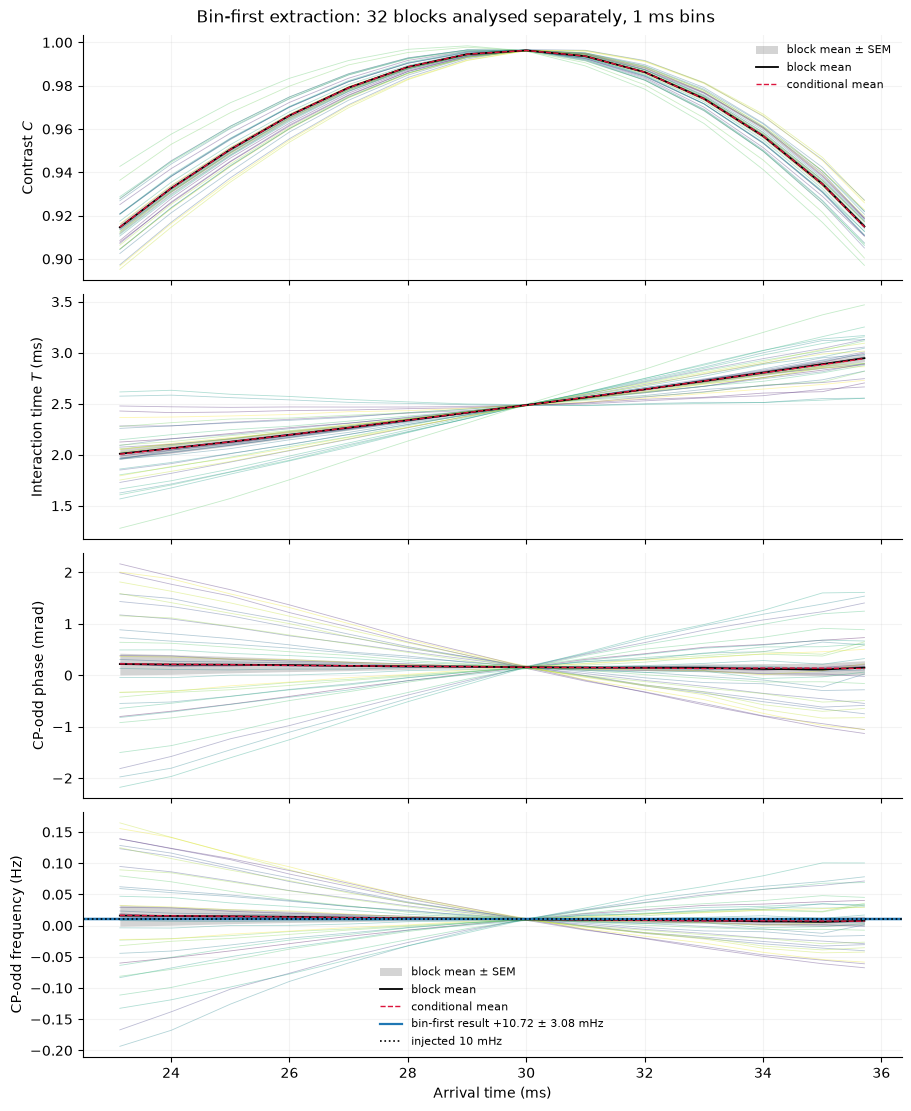

same run, injected f_CP = 10 mHz:
  pooled window estimate : +14.214 mHz (conditional sigma 0.043 mHz)
  bin-first estimate     : +10.725 +- 3.076 mHz (block SEM over 32 blocks)


In [10]:
def compare(cfg, seeds=(11, 12, 13, 14, 15), n_blocks=4, n_molecules=int(1e7),
            analysis_bin_width=None):
    """Pooled vs bin-first over several seeds. Returns two arrays of recovered f_CP."""
    abw = cfg.analysis_bin_width if analysis_bin_width is None else analysis_bin_width
    fld = si.ShortIRField(cfg)
    op = si.find_operating_phase(fld, cfg)
    pooled, binfirst = [], []
    for seed in seeds:
        out = si.run_short_ir_blocks(
            fld, cfg, n_blocks=n_blocks, n_molecules=n_molecules,
            detuning_hz=si.DETUNING_SWITCH_HZ,
            calibration_phase_rad=si.CALIBRATION_PHASE_RAD,
            cp_frequency_hz=F_CP, operating_phase_rad=op, seed=seed, verbose=False)
        pooled.append(float(si.extract(
            out["state_bins"], calibration_phase_rad=si.CALIBRATION_PHASE_RAD,
            detuning_hz=si.DETUNING_SWITCH_HZ)["aggregate"]["cp_frequency_hz"]))
        bf = si.extract_bin_first(
            out, calibration_phase_rad=si.CALIBRATION_PHASE_RAD,
            detuning_hz=si.DETUNING_SWITCH_HZ, bin_width=abw)
        binfirst.append(bf["combined"]["frequency_hz"])
    return np.array(pooled), np.array(binfirst)


warnings.filterwarnings("ignore")
print(f"injected f_CP = {F_CP:.5f} Hz, analysis bin "
      f"{CFG.analysis_bin_width*1e6:.0f} us\n")
print(f"{'v_shot':>7} {'estimator':>11} {'mean':>10} {'bias':>10} {'SD':>10}")
rows = {}
for vs in (0.0, CFG.shot_velocity_spread):
    p, b = compare(dataclasses.replace(CFG, shot_velocity_spread=vs))
    rows[vs] = (p, b)
    for nm, a in [("pooled", p), ("bin-first", b)]:
        print(f"{vs:>7.1f} {nm:>11} {a.mean():>10.5f} {a.mean()-F_CP:>+10.5f} "
              f"{a.std(ddof=1):>10.5f}")
p4, b4 = rows[CFG.shot_velocity_spread]
print(f"\nwith the 4 m/s shot scatter, bin-first cuts the seed-to-seed spread by "
      f"{p4.std(ddof=1)/b4.std(ddof=1):.1f}x")
print("The pooled estimator is the one that degrades when shot scatter is switched on;")
print("bin-first is nearly indifferent to it. That is the whole point of the method.")

# ---- bin-first view of the same run as the pooled four-panel figure ----
# Same data as the pooled figure above (OUT from the three-switch run), but analysed the
# bin-first way: each BLOCK separately, 1 ms analysis bins. Thin lines = individual blocks,
# black = mean over blocks, grey band = SEM over blocks, dashed = conditional mean.
# The per-bin ratio in the bottom panel is shown for comparison only; the bin-first RESULT
# is the per-block through-origin fit A_cp = r A_d across bins, then a plain mean over
# blocks (horizontal band).
BF = si.extract_bin_first(OUT, calibration_phase_rad=si.CALIBRATION_PHASE_RAD,
                          detuning_hz=si.DETUNING_SWITCH_HZ,
                          bin_width=CFG.analysis_bin_width)
PB, BFC = BF["per_bin"], BF["combined"]
grouped = PB.groupby("time_bin", sort=True)
t_c = 1e3*grouped["time_center_s"].mean()

fig, axes = plt.subplots(4, 1, figsize=(9, 11), sharex=True, constrained_layout=True)
series = [("contrast", "expected_contrast", 1.0, "Contrast $C$"),
          ("interaction_time_s", "expected_interaction_time_s", 1e3,
           "Interaction time $T$ (ms)"),
          ("cp_phase_rad", "expected_cp_phase_rad", 1e3, "CP-odd phase (mrad)"),
          ("cp_frequency_hz", "expected_cp_frequency_hz", 1.0, "CP-odd frequency (Hz)")]
block_colors = plt.cm.viridis(np.linspace(0, 1, PB["block"].nunique()))
for ax, (val, exp, scale, ylabel) in zip(axes, series):
    for color, (_, blk) in zip(block_colors, PB.groupby("block", sort=True)):
        blk = blk.sort_values("time_center_s")
        ax.plot(1e3*blk["time_center_s"], scale*blk[val], color=color, lw=0.6, alpha=0.35)
    mean = scale*grouped[val].mean()
    sem = scale*grouped[val].sem(ddof=1)
    ax.fill_between(t_c, mean - sem, mean + sem, color="0.45", alpha=0.3, lw=0,
                    label="block mean $\\pm$ SEM")
    ax.plot(t_c, mean, color="black", lw=1.3, label="block mean")
    ax.plot(t_c, scale*grouped[exp].mean(), "--", color="crimson", lw=1.0,
            label="conditional mean")
    ax.set_ylabel(ylabel); ax.grid(alpha=.15)
    ax.spines[["top", "right"]].set_visible(False)
ax = axes[-1]
ax.axhspan(BFC["frequency_hz"] - BFC["block_sem_hz"], BFC["frequency_hz"] + BFC["block_sem_hz"],
           color="#1f77b4", alpha=0.18, lw=0)
ax.axhline(BFC["frequency_hz"], color="#1f77b4", lw=1.6,
           label=f"bin-first result {BFC['frequency_hz']*1e3:+.2f} $\\pm$ "
                 f"{BFC['block_sem_hz']*1e3:.2f} mHz")
ax.axhline(F_CP, color="k", ls=":", lw=1.2, label=f"injected {F_CP*1e3:g} mHz")
axes[0].legend(fontsize=8, frameon=False)
axes[-1].legend(fontsize=8, frameon=False, loc="best")
axes[-1].set_xlabel("Arrival time (ms)")
fig.suptitle(f"Bin-first extraction: {BFC['n_blocks']} blocks analysed separately, "
             f"{CFG.analysis_bin_width*1e3:g} ms bins", fontsize=12)
plt.show()

POOLED = si.extract(STATE_BINS, calibration_phase_rad=si.CALIBRATION_PHASE_RAD,
                    detuning_hz=si.DETUNING_SWITCH_HZ)["aggregate"]
print(f"same run, injected f_CP = {F_CP*1e3:g} mHz:")
print(f"  pooled window estimate : {POOLED['cp_frequency_hz']*1e3:+.3f} mHz "
      f"(conditional sigma {POOLED['sigma_cp_frequency_hz']*1e3:.3f} mHz)")
print(f"  bin-first estimate     : {BFC['frequency_hz']*1e3:+.3f} +- "
      f"{BFC['block_sem_hz']*1e3:.3f} mHz (block SEM over {BFC['n_blocks']} blocks)")


## Optimising the RF amplitude

A shot whose mean velocity is a few m/s off spends a different time in the RF field, so
**every** molecule in it gets a slightly different pulse area. At Emma's `FIELD_SCALE`
0.365 the peak of $P_e(v)$ sits at ~175 m/s, not at the 184 m/s beam mean, so the
asymmetry responds to the shot velocity to first order. Across the eight shots of a block
the velocities are independent, and they leak into the EDM channel through their CP-odd
combination

$$\delta v_c=\frac18\sum_i c_i\,\bar v_{{\rm shot},i}$$

-- a fake $f_{\rm CP}$ proportional to $\delta v_c$. Raising the RF amplitude until the local
slope $dA/dv$ vanishes at the beam mean removes that coupling.

**Which null?** Two definitions give different amplitudes:

* the **local** null, $dA/dv=0$ at 184 m/s (the $P_e(v)$ peak moved onto the beam mean);
* the **shot-averaged** null, $d\langle A\rangle_{\rm shot}/d\bar v_{\rm shot}=0$, where the
  average over the 16 m/s spread lets the curvature of $A(v)$ move the zero.

The bin-first extraction analyses one velocity slice per arrival bin, so it should care
about the local slope; the pooled estimator sees the shot average. The measurement below
compares Emma's 0.365 with both.

**Paired beam.** `shot_mean_seed` gives all three amplitudes the *same* shot-mean
velocities and the *same* switch ordering, so the only difference between them is the RF
amplitude. Readout is the explicit LIF model; $f_{\rm CP}$ = 0.1 Hz.

This changes Emma's `FIELD_SCALE`, which the rest of the notebook deliberately does not;
it is done only in this section.


local null (dA/dv = 0 at 184 m/s)          : FIELD_SCALE = 0.3828 (+4.9%)
shot-averaged null (d<A>/dvbar = 0)       : FIELD_SCALE = 0.3747 (+2.7%)


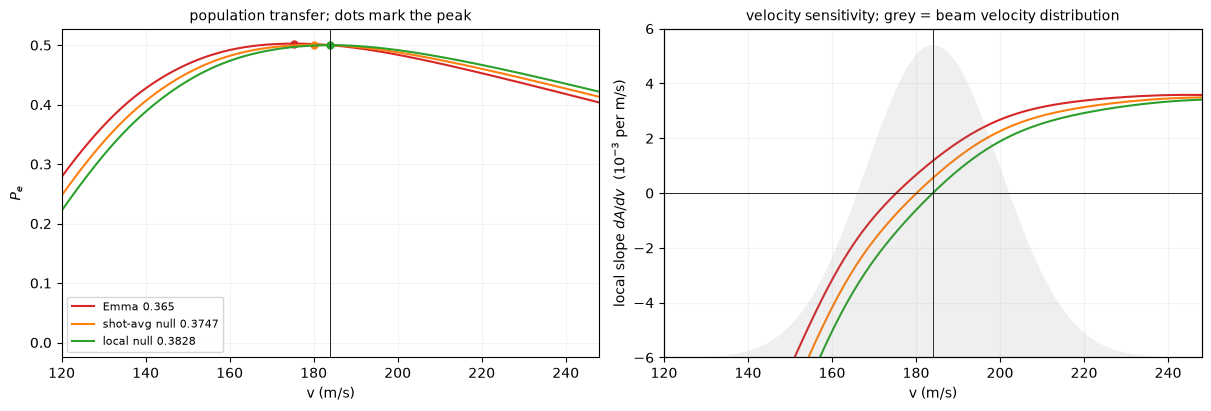


RMS whole-shot asymmetry jitter caused by the 4 m/s shot-to-shot velocity scatter
(what the POOLED estimator sees):
  Emma 0.365             2.87e-03
  shot-avg null 0.3747   1.68e-03
  local null 0.3828      3.00e-03
The shot-averaged null minimises this. The bin-first extraction instead follows
the LOCAL slope at the beam mean -- the measurement below shows which matters.


In [11]:
from scipy.optimize import brentq

VV = np.linspace(CFG.mean_velocity - 7*CFG.velocity_spread,
                 CFG.mean_velocity + 7*CFG.velocity_spread, 1201)
V0 = CFG.mean_velocity


def amplitude_setup(scale):
    """Config, field and operating phase at a given RF amplitude, plus A(v) on VV.

    The operating phase is re-solved at every amplitude: each amplitude is its own
    working point with A = 0 at the beam mean.
    """
    cfg = dataclasses.replace(CFG, field_scale=scale)
    fld = si.ShortIRField(cfg)
    op = si.find_operating_phase(fld, cfg)
    pe = si.propagate_velocities(fld, VV, phase_2=op, b_par_G=cfg.b_par_G,
                                 dnu_dB_par=cfg.dnu_dB_par,
                                 dnu_transverse_Hz=cfg.dnu_transverse_Hz)
    return cfg, fld, op, 1 - 2*pe


def shot_average(A, vbar):
    """Expected whole-shot asymmetry for a shot whose mean velocity is vbar."""
    w = np.exp(-0.5*((VV - vbar)/CFG.velocity_spread)**2)
    return np.trapezoid(A*w, VV) / np.trapezoid(w, VV)


def local_slope(scale, h=0.5):
    *_, A = amplitude_setup(scale)
    return (np.interp(V0 + h, VV, A) - np.interp(V0 - h, VV, A)) / (2*h)


def shot_slope(scale, h=1.0):
    *_, A = amplitude_setup(scale)
    return (shot_average(A, V0 + h) - shot_average(A, V0 - h)) / (2*h)


AMP_LOCAL = brentq(local_slope, 0.375, 0.395, xtol=1e-5)
AMP_SHOT = brentq(shot_slope, 0.365, 0.380, xtol=1e-5)
AMPS = {"Emma 0.365": 0.365,
        f"shot-avg null {AMP_SHOT:.4f}": AMP_SHOT,
        f"local null {AMP_LOCAL:.4f}": AMP_LOCAL}
SETUPS = {label: amplitude_setup(s) for label, s in AMPS.items()}
COLORS = dict(zip(AMPS, ("#d62728", "#ff7f0e", "#2ca02c")))

print(f"local null (dA/dv = 0 at {V0:.0f} m/s)          : FIELD_SCALE = {AMP_LOCAL:.4f} "
      f"({(AMP_LOCAL/0.365-1)*100:+.1f}%)")
print(f"shot-averaged null (d<A>/dvbar = 0)       : FIELD_SCALE = {AMP_SHOT:.4f} "
      f"({(AMP_SHOT/0.365-1)*100:+.1f}%)")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.0), constrained_layout=True)
dens = np.exp(-0.5*((VV - V0)/CFG.velocity_spread)**2)
for label, (cfg, fld, op, A) in SETUPS.items():
    pe = (1 - A)/2
    axL.plot(VV, pe, color=COLORS[label], label=label)
    axL.plot(VV[np.argmax(pe)], pe.max(), "o", ms=5, color=COLORS[label])
    axR.plot(VV, 1e3*np.gradient(A, VV), color=COLORS[label], label=label)
for ax in (axL, axR):
    ax.axvline(V0, color="k", lw=0.6)
    ax.set_xlim(V0 - 4*CFG.velocity_spread, V0 + 4*CFG.velocity_spread)
    ax.set_xlabel("v (m/s)"); ax.grid(alpha=.15)
axL.set_ylabel("$P_e$"); axL.set_title("population transfer; dots mark the peak", fontsize=10)
axL.legend(fontsize=8)
axR.axhline(0, color="k", lw=0.6)
ax2 = axR.twinx(); ax2.fill_between(VV, dens, color="grey", alpha=.12, lw=0)
ax2.set_yticks([]); ax2.set_ylim(0, 1.05)
axR.set_ylim(-6, 6)
axR.set_ylabel(r"local slope $dA/dv$  ($10^{-3}$ per m/s)")
axR.set_title("velocity sensitivity; grey = beam velocity distribution", fontsize=10)
plt.show()

print(f"\nRMS whole-shot asymmetry jitter caused by the {CFG.shot_velocity_spread:.0f} m/s "
      f"shot-to-shot velocity scatter\n(what the POOLED estimator sees):")
z = np.linspace(-4, 4, 161); wz = np.exp(-0.5*z**2); wz /= wz.sum()
for label, (cfg, fld, op, A) in SETUPS.items():
    ea = np.array([shot_average(A, V0 + CFG.shot_velocity_spread*zi) for zi in z])
    rms = np.sqrt(np.sum(wz*(ea - np.sum(wz*ea))**2))
    print(f"  {label:<22} {rms:.2e}")
print("The shot-averaged null minimises this. The bin-first extraction instead follows")
print("the LOCAL slope at the beam mean -- the measurement below shows which matters.")


In [12]:
# AMP_RUNS, AMP_BLOCKS = 6, 16
# AMP_KW = dict(calibration_phase_rad=si.CALIBRATION_PHASE_RAD,
#               detuning_hz=si.DETUNING_SWITCH_HZ, bin_width=CFG.analysis_bin_width)

# AMP_RES = {}
# t0 = time.perf_counter()
# for label, (cfg, fld, op, _) in SETUPS.items():
#     rec = dict(lif_runs=[], lif_err=[], lif_blocks=[], proj_blocks=[], dvc=[])
#     for r in range(AMP_RUNS):
#         # Same beam and schedule at every amplitude: only the RF amplitude differs.
#         out = si.run_short_ir_blocks(
#             fld, cfg, n_blocks=AMP_BLOCKS, n_molecules=int(1e7),
#             detuning_hz=si.DETUNING_SWITCH_HZ,
#             calibration_phase_rad=si.CALIBRATION_PHASE_RAD,
#             cp_frequency_hz=F_CP, operating_phase_rad=op,
#             seed=40000 + 101*r, schedule_seed=41000 + 101*r,
#             shot_mean_seed=42000 + 101*r, verbose=False)
#         summ = out["summary"]
#         rec["dvc"] += ((summ.cp_state*summ.shot_mean).groupby(summ.block).sum()/8
#                        ).sort_index().tolist()
#         rec["proj_blocks"] += si.extract_bin_first(out, **AMP_KW)["blocks"][
#             "frequency_hz"].tolist()
#         lit = si.apply_fluorescence_to_run(out, cfg, seed=43000 + 101*r, verbose=False)
#         lif = si.extract_bin_first_fluorescence(lit, **AMP_KW)
#         rec["lif_blocks"] += lif["blocks"]["frequency_hz"].tolist()
#         rec["lif_runs"].append(lif["combined"]["frequency_hz"])
#         rec["lif_err"].append(lif["combined"]["block_sem_hz"])
#     AMP_RES[label] = {k: np.array(v) for k, v in rec.items()}
#     print(f"{label:<22} done at {time.perf_counter()-t0:.0f} s")

# # ---- figure 1: the fake EDM signal from velocity scatter ---------------------
# fig, axes = plt.subplots(1, len(AMPS), figsize=(13, 3.8), sharey=True,
#                          constrained_layout=True)
# for ax, (label, rec) in zip(axes, AMP_RES.items()):
#     x, y = rec["dvc"], rec["lif_blocks"]
#     k, b = np.polyfit(x, y, 1); r = np.corrcoef(x, y)[0, 1]
#     xx = np.linspace(x.min(), x.max(), 2)
#     ax.plot(x, y, "o", ms=4, alpha=.6, color=COLORS[label])
#     ax.plot(xx, k*xx + b, "k-", lw=1.2)
#     ax.axhline(F_CP, color="crimson", ls="--", lw=1.0)
#     ax.set_title(f"{label}\nslope {k*1e3:+.1f} mHz per m/s,  r = {r:+.2f}", fontsize=10)
#     ax.set_xlabel(r"block velocity imbalance $\delta v_c$ (m/s)"); ax.grid(alpha=.15)
# axes[0].set_ylabel(r"per-block $f_{CP}$ (Hz), LIF readout")
# fig.suptitle("Each point is one eight-shot block. A slope means the beam velocity is "
#              "faking an EDM signal.", fontsize=11)
# plt.show()

# # ---- figure 2: the EDM measurement itself ------------------------------------
# fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.0),
#                                gridspec_kw=dict(width_ratios=[1.6, 1]),
#                                constrained_layout=True)
# width = 0.25
# for j, (label, rec) in enumerate(AMP_RES.items()):
#     idx = np.arange(AMP_RUNS) + (j - 1)*width
#     axL.errorbar(idx, rec["lif_runs"], yerr=rec["lif_err"], fmt="o", ms=5, capsize=3,
#                  color=COLORS[label], label=f"{label}: mean error bar "
#                  f"{rec['lif_err'].mean()*1e3:.1f} mHz")
# axL.axhline(F_CP, color="crimson", ls="--", lw=1.0, label="injected")
# axL.set_xticks(range(AMP_RUNS)); axL.set_xlabel("run (same beam for all three amplitudes)")
# axL.set_ylabel(r"$f_{CP}$ (Hz)")
# axL.set_title(f"{AMP_RUNS} runs x {AMP_BLOCKS} blocks, LIF readout", fontsize=10)
# axL.legend(fontsize=8); axL.grid(alpha=.15)

# nblk = AMP_RUNS*AMP_BLOCKS
# rel = 1/np.sqrt(2*(nblk - 1))                      # relative uncertainty of an SD
# for j, readout in enumerate(("lif_blocks", "proj_blocks")):
#     sds = np.array([rec[readout].std(ddof=1) for rec in AMP_RES.values()])
#     xpos = np.arange(len(AMPS)) + (j - 0.5)*0.36
#     axR.bar(xpos, 1e3*sds, width=0.34, yerr=1e3*sds*rel, capsize=3,
#             color=list(COLORS.values()), alpha=1.0 if j == 0 else 0.35,
#             edgecolor="k", lw=0.6,
#             label="LIF readout" if j == 0 else "projection only (no photon noise)")
# axR.set_xticks(range(len(AMPS))); axR.set_xticklabels(list(AMPS), fontsize=8)
# axR.set_ylabel("per-block scatter of $f_{CP}$ (mHz)")
# axR.set_title("sensitivity per block", fontsize=10)
# axR.legend(fontsize=8); axR.grid(alpha=.15, axis="y")
# plt.show()

# ref = next(iter(AMP_RES))
# sd_ref = {k: AMP_RES[ref][k].std(ddof=1) for k in ("lif_blocks", "proj_blocks")}
# print(f"\nper-block scatter, {nblk} blocks each (each SD known to {rel*100:.1f}%)")
# print(f"{'amplitude':<22} {'LIF [mHz]':>10} {'ratio':>6} {'beam time':>10} | "
#       f"{'proj [mHz]':>10} {'ratio':>6}")
# for label, rec in AMP_RES.items():
#     lif = rec["lif_blocks"].std(ddof=1); prj = rec["proj_blocks"].std(ddof=1)
#     print(f"{label:<22} {lif*1e3:>10.2f} {lif/sd_ref['lif_blocks']:>6.2f} "
#           f"{(lif/sd_ref['lif_blocks'])**2:>9.0%} | {prj*1e3:>10.2f} "
#           f"{prj/sd_ref['proj_blocks']:>6.2f}")
# print("\n'beam time' = integration time needed for the same sensitivity, relative to 0.365.")
# print("Projection-only shows the velocity term on its own; with the LIF readout the")
# print("photon noise, which the RF amplitude cannot touch, dilutes the gain.")


## Motional magnetic field

The one-directional $B_\parallel$ drift is common to all eight switch states and the parity
estimators reject it. A magnetic effect enters the EDM channel only if it is **odd under the
E reversal**, and the motional field is the textbook case. A molecule moving at $\mathbf v$
through $\boldsymbol{\mathcal E}$ sees

$$\mathbf B_{\rm mot}=\frac{\mathbf v\times\boldsymbol{\mathcal E}}{c^2},\qquad
|B_{\rm mot}|=60.8\ \mu\text{G at 184 m/s and 29.7 kV/cm},$$

transverse to both $\mathbf v$ and $\boldsymbol{\mathcal E}$, and reversing with E. With a
static field $b_\perp$ along the same axis, the second-order transverse Zeeman shift
$\kappa(b_\perp+B_{\rm mot})^2$ acquires the E-odd cross term

$$\delta\nu_{\rm CP,fake}=2\kappa\,b_\perp B_{\rm mot}\ \propto\ b_\perp\,v,
\qquad \kappa=207.5\ \text{Hz/G}^2 .$$

That is 25.1 nHz per µG of $b_\perp$, i.e. 50.2 nHz/µG between $+\mathcal E$ and $-\mathcal E$ --
the CeNTREX proposal (arXiv:2010.01451, §3.3.2) quotes ≈50 nHz/µG for the main IR. It is the
mechanism behind the main IR's sub-10 µG shielding target.

**What is in the model.** `ShortIRConfig.include_motional_field` (on), `b_perp_motional_G`
(−0.80 mG: the record's position is quoted as z = 44–88 cm, so its z is the beam axis and By
is the component perpendicular to both $\mathbf v$ and $\boldsymbol{\mathcal E}$ -- an
inferred assignment) and the fixed coefficient `transverse_zeeman_Hz_per_G2`. The CP switch
is taken to be the E reversal and sets the sign of $B_{\rm mot}$; the propagator carries the
velocity- and $z$-dependent shift, including the fringe-field region.

**Not in the model.** CeNTREX's M modulation (switching between the e↔j and h↔k pairs)
suppresses this shift to the difference between the two pairs. The proposal quotes
≈50 nHz/µG for one pair and ≈5.6 nHz/µG for the difference; only their RATIO, ≈8.9, is
independent of how the shift is defined, so in this notebook's convention (the extracted
$f_{\rm CP}$, i.e. half the $\pm\mathcal E$ difference) M modulation gives
25.1/8.9 ≈ 2.8 nHz/µG. This notebook has only the j/e pair, so the headline numbers are
the unsuppressed ones.


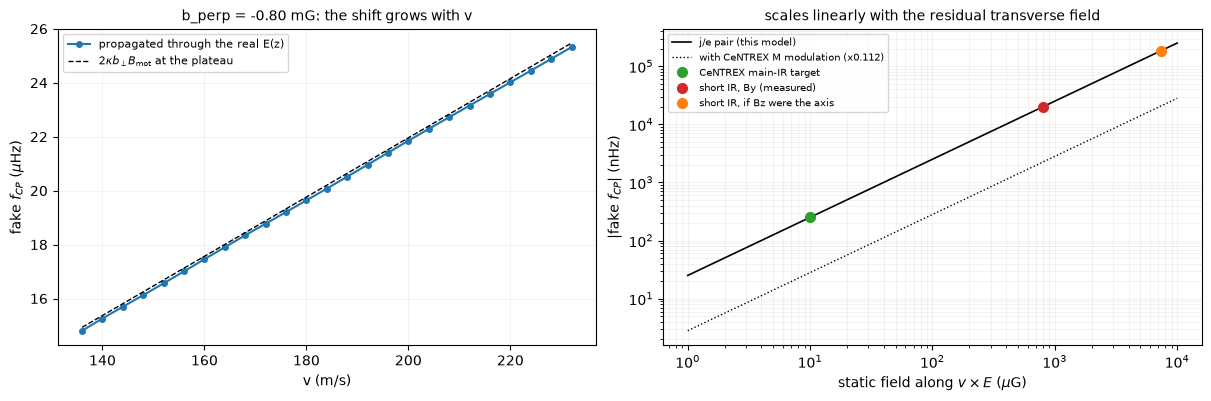

B_mot at 184 m/s and 29.72 kV/cm: 60.8 uG
coupling: -25.09 nHz per uG of b_perp (half the +E/-E difference; CeNTREX quotes ~50 nHz/uG for the difference)
beam-averaged fake f_CP at b_perp = -0.80 mG: +20.08 uHz   (propagated / plateau analytic at 184 m/s: 0.9938)

statistical reach: 24.2 mHz per block (LIF, local null, 1e7/shot)
  x 300 h at 50 Hz = 6.75e+06 blocks -> 9.31 uHz
  CeNTREX main-IR target         b_perp =  0.010 mG -> fake    0.251 uHz =   0.03 x reach (M-suppressed:  0.00 x)
  short IR, By (measured)        b_perp =  0.800 mG -> fake   20.075 uHz =   2.16 x reach (M-suppressed:  0.24 x)
  short IR, if Bz were the axis  b_perp =  7.400 mG -> fake  185.693 uHz =  19.94 x reach (M-suppressed:  2.23 x)


In [13]:
from short_ir.ramsey import motional_args, C_LIGHT

MOT_CFG = dataclasses.replace(CFG, field_scale=AMP_LOCAL if "AMP_LOCAL" in globals() else 0.3828)
MOT_FIELD = si.ShortIRField(MOT_CFG)
MOT_OP = si.find_operating_phase(MOT_FIELD, MOT_CFG)
MOT_KW = dict(b_par_G=MOT_CFG.b_par_G, dnu_dB_par=MOT_CFG.dnu_dB_par,
              dnu_transverse_Hz=MOT_CFG.dnu_transverse_Hz)


def fake_fcp(cfg, velocities):
    """Noiseless CP-odd frequency from the three-switch parities, velocity by velocity.

    Deterministic: the eight switch states are propagated exactly and the parities
    A_cp, A_d are formed from the resulting asymmetries, so there is no sampling noise --
    the only way to see a 1e-5 Hz effect under a 1e-2 Hz-per-run noise floor.
    """
    A = {}
    for d in (1, -1):
        for p in (1, -1):
            for c in (1, -1):
                pe = si.propagate_velocities(
                    MOT_FIELD, velocities, phase_2=MOT_OP + p*si.CALIBRATION_PHASE_RAD,
                    detuning_Hz=d*si.DETUNING_SWITCH_HZ, motional=motional_args(cfg, c),
                    **MOT_KW)
                A[(d, p, c)] = 1 - 2*pe
    A_cp = np.mean([k[2]*A[k] for k in A], axis=0)
    A_d = np.mean([k[0]*A[k] for k in A], axis=0)
    return si.DETUNING_SWITCH_HZ * A_cp / A_d


vv = np.linspace(CFG.mean_velocity - 3*CFG.velocity_spread,
                 CFG.mean_velocity + 3*CFG.velocity_spread, 25)
f_v = fake_fcp(MOT_CFG, vv)
kap = MOT_CFG.transverse_zeeman_Hz_per_G2
analytic = 2*kap*MOT_CFG.b_perp_motional_G*(-vv*MOT_FIELD.E_plateau*1e5/C_LIGHT**2*1e4)
wv = np.exp(-0.5*((vv - CFG.mean_velocity)/CFG.velocity_spread)**2)
f_beam = np.sum(wv*f_v)/np.sum(wv)

M_SUPPRESSION = 5.6/50.0   # CeNTREX pair-difference / single-pair ratio (convention-free)
B_LEVELS = {"CeNTREX main-IR target": 10e-6, "short IR, By (measured)": 0.80e-3,
            "short IR, if Bz were the axis": 7.40e-3}
coef = fake_fcp(dataclasses.replace(MOT_CFG, b_perp_motional_G=+1e-6),
                np.array([CFG.mean_velocity]))[0]            # Hz per uG of b_perp

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 3.9), constrained_layout=True)
axL.plot(vv, 1e6*f_v, "o-", ms=4, label="propagated through the real E(z)")
axL.plot(vv, 1e6*analytic, "k--", lw=1, label=r"$2\kappa b_\perp B_{\rm mot}$ at the plateau")
axL.set_xlabel("v (m/s)"); axL.set_ylabel(r"fake $f_{CP}$ ($\mu$Hz)")
axL.set_title(f"b_perp = {MOT_CFG.b_perp_motional_G*1e3:+.2f} mG: the shift grows with v",
              fontsize=10)
axL.legend(fontsize=8); axL.grid(alpha=.15)
bb = np.logspace(-6, -2, 50)
axR.loglog(bb*1e6, np.abs(coef)*bb*1e6*1e9, "k-", lw=1.2, label="j/e pair (this model)")
axR.loglog(bb*1e6, np.abs(coef)*M_SUPPRESSION*bb*1e6*1e9, "k:", lw=1.0,
           label=f"with CeNTREX M modulation (x{M_SUPPRESSION:.3f})")
for (label, b), col in zip(B_LEVELS.items(), ("#2ca02c", "#d62728", "#ff7f0e")):
    axR.plot(b*1e6, np.abs(coef)*b*1e6*1e9, "o", ms=7, color=col, label=label)
axR.set_xlabel(r"static field along $v\times E$ ($\mu$G)")
axR.set_ylabel(r"|fake $f_{CP}$| (nHz)")
axR.set_title("scales linearly with the residual transverse field", fontsize=10)
axR.legend(fontsize=7); axR.grid(alpha=.15, which="both")
plt.show()

print(f"B_mot at {CFG.mean_velocity:.0f} m/s and {MOT_FIELD.E_plateau:.2f} kV/cm: "
      f"{CFG.mean_velocity*MOT_FIELD.E_plateau*1e5/C_LIGHT**2*1e10:.1f} uG")
print(f"coupling: {coef*1e9:+.2f} nHz per uG of b_perp (half the +E/-E difference; "
      f"CeNTREX quotes ~50 nHz/uG for the difference)")
print(f"beam-averaged fake f_CP at b_perp = {MOT_CFG.b_perp_motional_G*1e3:+.2f} mG: "
      f"{f_beam*1e6:+.2f} uHz   (propagated / plateau analytic at 184 m/s: "
      f"{np.interp(CFG.mean_velocity, vv, f_v/analytic):.4f})\n")

# How large is that against the statistical reach of a long run?
sigma_block = (AMP_RES[list(AMP_RES)[-1]]["lif_blocks"].std(ddof=1)
               if "AMP_RES" in globals() else 24.2e-3)          # Hz per 8-shot block
REP_HZ, HOURS = 50.0, 300.0                                     # CeNTREX proposal numbers
blocks = REP_HZ*HOURS*3600/8
reach = sigma_block/np.sqrt(blocks)
print(f"statistical reach: {sigma_block*1e3:.1f} mHz per block (LIF, local null, 1e7/shot)")
print(f"  x {HOURS:.0f} h at {REP_HZ:.0f} Hz = {blocks:.2e} blocks -> {reach*1e6:.2f} uHz")
for label, b in B_LEVELS.items():
    fk = abs(coef)*b*1e6
    print(f"  {label:<30} b_perp = {b*1e3:6.3f} mG -> fake {fk*1e6:8.3f} uHz "
          f"= {fk/reach:6.2f} x reach (M-suppressed: {fk*M_SUPPRESSION/reach:5.2f} x)")


In [14]:
# Intentional parameter variation (ACME's method): at the real b_perp the fake signal is
# ~20 uHz, invisible under the MC noise. Exaggerate b_perp to +-0.4 G (fake ~ -+10 mHz) and
# check that the full chain -- switch tables, sampler, LIF readout, bin-first fit --
# transmits it with the deterministic coefficient. Only the E-odd cross term is scaled;
# the static transverse shift stays at the measured dnu_transverse_Hz.
#
# Validation only: nothing downstream uses its results, and it takes ~5 min. Set to
# True when the motional-field code or its inputs (RF amplitude, E field, velocity,
# kappa, readout, extraction) change. n_molecules = 1e10 would sharpen the check ~7x
# at the same run time.
RUN_MOTIONAL_IPV = False

if RUN_MOTIONAL_IPV:
    IPV_B, IPV_RUNS, IPV_BLOCKS = 0.4, 6, 16
    ipv = {}
    t0 = time.perf_counter()
    for bp in (+IPV_B, -IPV_B):
        cfg_i = dataclasses.replace(MOT_CFG, b_perp_motional_G=bp)
        vals = []
        for r in range(IPV_RUNS):
            out = si.run_short_ir_blocks(
                MOT_FIELD, cfg_i, n_blocks=IPV_BLOCKS, n_molecules=int(1e10),
                detuning_hz=si.DETUNING_SWITCH_HZ,
                calibration_phase_rad=si.CALIBRATION_PHASE_RAD, cp_frequency_hz=0.0,
                operating_phase_rad=MOT_OP, seed=70000 + 31*r, schedule_seed=71000 + 31*r,
                shot_mean_seed=72000 + 31*r, verbose=False)
            lit = si.apply_fluorescence_to_run(out, cfg_i, seed=73000 + 31*r, verbose=False)
            vals += si.extract_bin_first_fluorescence(
                lit, calibration_phase_rad=si.CALIBRATION_PHASE_RAD,
                detuning_hz=si.DETUNING_SWITCH_HZ,
                bin_width=cfg_i.analysis_bin_width)["blocks"]["frequency_hz"].tolist()
        ipv[bp] = np.array(vals)
        print(f"b_perp {bp:+.2f} G: f_CP = {ipv[bp].mean()*1e3:+.2f} +- "
              f"{ipv[bp].std(ddof=1)/np.sqrt(ipv[bp].size)*1e3:.2f} mHz   "
              f"(deterministic {coef*bp*1e6*1e3:+.2f} mHz)  [{time.perf_counter()-t0:.0f} s]")
    half = (ipv[IPV_B].mean() - ipv[-IPV_B].mean())/2
    half_err = np.hypot(*(ipv[b].std(ddof=1)/np.sqrt(ipv[b].size) for b in ipv))/2
    print(f"\nMC coupling {half/(IPV_B*1e6)*1e9:+.2f} +- {half_err/(IPV_B*1e6)*1e9:.2f} nHz/uG, "
          f"deterministic {coef*1e9:+.2f} nHz/uG")
else:
    print('Motional-field IPV check skipped (RUN_MOTIONAL_IPV = False).')


Motional-field IPV check skipped (RUN_MOTIONAL_IPV = False).


## Open items

1. **B-field drift** is now in the campaign: a one-directional $B_\parallel$ drift, default
   0.0667 mG/day ($-0.166$ Hz/day), one run per day, field constant within a run, operating
   phase frozen at day 0. At that rate it is **common mode**: it walks the fringe offset
   $A_0$ exactly as predicted ($-2.4\times10^{-3}$/day) but leaves $f_{\rm CP}$ and its error
   bar unchanged over 20 days. At 10x the rate the working point slides far off the zero
   crossing ($A_0\to-0.43$, contrast $0.98\to0.89$) and the error bar grows ~50%; daily
   re-tuning of the operating phase would remove that. Still open: transverse-component
   drift, non-monotonic (e.g. diurnal) drift, and drift WITHIN a run, which matters only
   if a run lasts long enough for the field to move.
2. **Background light** is not modelled (nor is it in `centrex_asymmetry`). It adds directly
   to the photon noise, which is already the dominant term.
3. **Velocity model.** Emma's script hardcodes 180 m/s; this uses 184 ± 16 with a 4 m/s
   shot-mean scatter. With the LIF readout that scatter is ~30% of the variance at
   `FIELD_SCALE` 0.365, so its real value matters, and it sets how much the RF-amplitude
   trim is worth.
4. **Start-time spread** (1 ms assumed) sets the TOF velocity resolution and hence the
   analysis bin width.
5. **8-level manifold** is out of scope by construction. The two-level notebook puts the
   pulse pull at +0.16 Hz scaling as $B_{\rm RF}^2$; being common to all eight switch states it
   cancels in the parity estimators.


## A simulated data-taking campaign

Everything above characterises the *estimator*. This section asks the question an EDM
experiment actually asks: run the apparatus `N_RUNS` independent times, let each run
produce its own number and its own error bar, and see whether they average down.

Each run is `RUN_BLOCKS` complete eight-state blocks with an independent beam seed *and*
an independent switch ordering, read out through the LIF photon-cycling model.
The RF amplitude is set to the **local velocity null** found in the previous section
(`AMP_LOCAL`, ~0.383) rather than Emma's 0.365, which removes the velocity-scatter
contribution to the error bar (~0.73x).

**Magnetic-field drift.** Runs are one day apart (`run_spacing_days`), and $B_\parallel$ --
the only component that shifts $\nu_{je}$ at first order -- can drift in one direction at
`b_par_drift_G_per_day` -- **currently 0, off**. The measured record's ~0.05 mG per 18 h
would be 0.0667 mG/day ($-0.166$ Hz/day); at that rate the drift is common mode and
the parity estimators reject it. The motional field (see 'Motional magnetic field' above) is on. The field is constant within a run and the operating phase
is frozen at day 0, as it would be without daily re-tuning. The second figure checks
whether the EDM channel follows the drift. The error bar is the **empirical** block-to-block SEM,
not the conditional sigma propagated from counting statistics -- the conditional one
excludes shot-to-shot velocity scatter, ~30% of the variance here.

Two things to read off the plot:

* **Consistency.** The reduced chi-square of the runs about their weighted mean tests
  whether the quoted error bars are honest. $\chi^2_\nu\approx1$ means they are;
  $\chi^2_\nu\gg1$ means an unmodelled scatter (systematic drift) is present.
* **Averaging down.** The right panel is the running weighted mean. If the experiment
  is statistics-limited it must follow the $1/\sqrt{n}$ band; a floor would be the
  signature of a systematic.

* **Accuracy.** A small $\chi^2_\nu$ says the runs agree with *each other*, not with the
  truth. The pull of the combined mean against the injected value tests the latter.


B_par drift +0.0000 mG/day -> -0.0000 Hz/day in nu_je; operating phase frozen at day 0
motional field ON: b_perp = -0.80 mG -> fake f_CP ~ +20.2 uHz, far below this campaign's statistical error
campaign RF amplitude FIELD_SCALE = 0.3828 (Emma: 0.365), operating phase 1.6923 rad

day  0  B_par 0.450 mG:  f_CP = +0.01041 +- 0.00071 Hz   (conditional 0.00014)
day  1  B_par 0.450 mG:  f_CP = +0.01058 +- 0.00044 Hz   (conditional 0.00014)
day  2  B_par 0.450 mG:  f_CP = +0.00971 +- 0.00084 Hz   (conditional 0.00014)
day  3  B_par 0.450 mG:  f_CP = +0.01006 +- 0.00061 Hz   (conditional 0.00014)
day  4  B_par 0.450 mG:  f_CP = +0.01033 +- 0.00045 Hz   (conditional 0.00014)
day  5  B_par 0.450 mG:  f_CP = +0.00860 +- 0.00127 Hz   (conditional 0.00014)
day  6  B_par 0.450 mG:  f_CP = +0.01089 +- 0.00050 Hz   (conditional 0.00014)
day  7  B_par 0.450 mG:  f_CP = +0.00949 +- 0.00068 Hz   (conditional 0.00014)
day  8  B_par 0.450 mG:  f_CP = +0.00939 +- 0.00067 Hz   (conditional 0.00014)
day  9  B

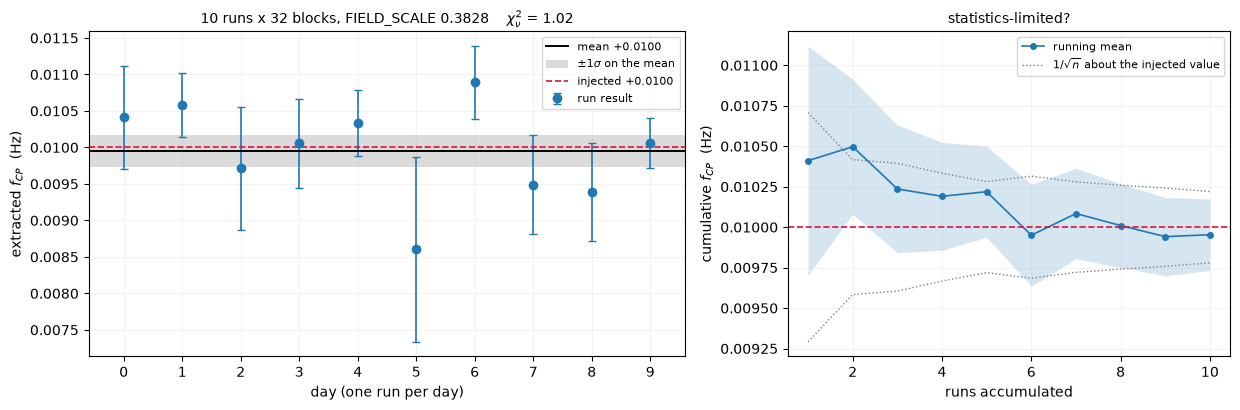


(a) error bars:  Birge ratio 1.01 -> the quoted uncertainties account for the run-to-run
    scatter. The runs are mutually consistent and average down as 1/sqrt(n).

(b) accuracy:    pull vs the injected value = -0.21 sigma -> consistent.

Statistical sensitivity after the whole campaign:
  0.00022 Hz   from the run scatter (LIF readout included)
  (2560 shots, 2.56e+13 molecules)

B_par drift is off (b_par_drift_G_per_day = 0): drift diagnostics skipped.


In [16]:
import time

N_RUNS     = 10
RUN_BLOCKS = 32          # eight-state blocks per run
RUN_MOL    = int(1e10)   # molecules per shot

# RF amplitude: the LOCAL velocity null (dA/dv = 0 at the beam mean), not Emma's 0.365.
# AMP_LOCAL is solved in the RF-amplitude section above; fall back to its value if that
# section has not been run in this kernel.
CAMPAIGN_SCALE = AMP_LOCAL if "AMP_LOCAL" in globals() else 0.3828
CAMP_CFG = dataclasses.replace(CFG, field_scale=CAMPAIGN_SCALE)
CAMP_FIELD = si.ShortIRField(CAMP_CFG)
CAMP_OP = si.find_operating_phase(CAMP_FIELD, CAMP_CFG)   # re-solved at this amplitude
# B_par drift: one run = CAMP_CFG.run_spacing_days (1 day). The field is constant within
# a run and steps between runs. Adjust the rate here (G/day; 0 switches it off):
CAMP_CFG = dataclasses.replace(CAMP_CFG,
                               b_par_drift_G_per_day=0.0,   # OFF; measured: 6.67e-5 G/day
                               run_spacing_days=1.0)
DNU_PER_DAY = CAMP_CFG.b_par_drift_G_per_day * CAMP_CFG.dnu_dB_par
print(f"B_par drift {CAMP_CFG.b_par_drift_G_per_day*1e3:+.4f} mG/day "
      f"-> {DNU_PER_DAY:+.4f} Hz/day in nu_je; operating phase frozen at day 0")
print(f"motional field {'ON' if CAMP_CFG.include_motional_field else 'OFF'}: "
      f"b_perp = {CAMP_CFG.b_perp_motional_G*1e3:+.2f} mG -> fake f_CP ~ "
      f"{2*CAMP_CFG.transverse_zeeman_Hz_per_G2*CAMP_CFG.b_perp_motional_G*(-60.8e-6)*1e6:+.1f}"
      f" uHz, far below this campaign's statistical error")
print(f"campaign RF amplitude FIELD_SCALE = {CAMPAIGN_SCALE:.4f} "
      f"(Emma: {CFG.field_scale}), operating phase {CAMP_OP:.4f} rad\n")

runs = []
t0 = time.perf_counter()
for r in range(N_RUNS):
    cfg_r = CAMP_CFG.drifted(r)            # B_par on day r
    out_r = si.run_short_ir_blocks(
        CAMP_FIELD, cfg_r, n_blocks=RUN_BLOCKS, n_molecules=RUN_MOL,
        detuning_hz=si.DETUNING_SWITCH_HZ,
        calibration_phase_rad=si.CALIBRATION_PHASE_RAD,
        cp_frequency_hz=F_CP, operating_phase_rad=CAMP_OP,
        seed=5000 + 137*r, schedule_seed=9000 + 137*r, verbose=False)
    lit_r = si.apply_fluorescence_to_run(out_r, cfg_r, seed=13000 + 137*r, verbose=False)
    ex = si.extract_bin_first_fluorescence(
        lit_r, calibration_phase_rad=si.CALIBRATION_PHASE_RAD,
        detuning_hz=si.DETUNING_SWITCH_HZ,
        bin_width=CAMP_CFG.analysis_bin_width)
    bf, win = ex["combined"], ex["window"]
    runs.append(dict(run=r, day=r*CAMP_CFG.run_spacing_days,
                     b_par_mG=cfg_r.b_par_G*1e3,
                     dnu_hz=(cfg_r.b_par_G - CAMP_CFG.b_par_G)*CAMP_CFG.dnu_dB_par,
                     A0=float(win["offset_asymmetry"]),
                     A_d=float(win["detuning_parity"]), contrast=bf["contrast"],
                     f=bf["frequency_hz"], err=bf["block_sem_hz"],
                     err_cond=bf["sigma_conditional_hz"]))
    print(f"day {r:2d}  B_par {cfg_r.b_par_G*1e3:.3f} mG:  "
          f"f_CP = {bf['frequency_hz']:+8.5f} "
          f"+- {bf['block_sem_hz']:.5f} Hz   "
          f"(conditional {bf['sigma_conditional_hz']:.5f})")
RUNS = pd.DataFrame(runs)
print(f"\n{N_RUNS} runs x {RUN_BLOCKS} blocks x 8 shots = "
      f"{N_RUNS*RUN_BLOCKS*8} shots in {time.perf_counter()-t0:.1f} s")

f, e = RUNS["f"].to_numpy(), RUNS["err"].to_numpy()

# PLAIN MEAN across runs. Each run's error bar is an empirical SEM that is itself
# uncertain; weighting by 1/SEM^2 would over-weight runs that happened to scatter little.
# All runs have the same statistical power, so a plain mean loses nothing.
f_wm = float(np.mean(f))                              # combined estimate
s_wm = float(np.sqrt(np.sum(e**2)) / f.size)          # internal error
s_ex = float(np.std(f, ddof=1) / np.sqrt(f.size))     # external error
chi2 = float(np.sum(((f - f_wm) / e)**2))             # still the right consistency test
nu   = f.size - 1
birge = np.sqrt(chi2 / nu)

print(f"\ncombined mean    f_CP = {f_wm:+.5f} +- {s_wm:.5f} Hz  (internal)")
print(f"                              +- {s_ex:.5f} Hz  (external, run scatter)")
print(f"injected                = {F_CP:+.5f} Hz   -> deviation "
      f"{(f_wm-F_CP)/s_wm:+.2f} sigma")
print(f"chi2/nu = {chi2:.2f}/{nu} = {chi2/nu:.2f},  Birge ratio = {birge:.2f}")
print("error bars include the LIF photon-counting noise (explicit cycling), the")
print("shot-to-shot velocity scatter and spin projection")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.5, 4.2),
                               gridspec_kw=dict(width_ratios=[1.35, 1]))

# --- left: the individual runs -----------------------------------------
axL.errorbar(RUNS["run"], f, yerr=e, fmt="o", ms=6, capsize=3, lw=1.2,
             color="#1f77b4", label="run result")
axL.axhline(f_wm, color="k", lw=1.4, label=f"mean {f_wm:+.4f}")
axL.fill_between([-0.6, N_RUNS-0.4], f_wm-s_wm, f_wm+s_wm,
                 color="k", alpha=.14, lw=0, label=r"$\pm1\sigma$ on the mean")
axL.axhline(F_CP, color="crimson", ls="--", lw=1.2, label=f"injected {F_CP:+.4f}")
axL.set_xlim(-0.6, N_RUNS-0.4)
axL.set_xticks(range(N_RUNS))
axL.set_xlabel("day (one run per day)")
axL.set_ylabel(r"extracted $f_{CP}$  (Hz)")
axL.set_title(f"{N_RUNS} runs x {RUN_BLOCKS} blocks, FIELD_SCALE {CAMPAIGN_SCALE:.4f}"
              rf"    $\chi^2_\nu$ = {chi2/nu:.2f}", fontsize=10)
axL.legend(fontsize=8, loc="best"); axL.grid(alpha=.15)

# --- right: does it average down? --------------------------------------
n = np.arange(1, f.size+1)
cw = np.cumsum(f) / n
cs = np.sqrt(np.cumsum(e**2)) / n
axR.plot(n, cw, "o-", ms=4, lw=1.2, color="#1f77b4", label="running mean")
axR.fill_between(n, cw-cs, cw+cs, color="#1f77b4", alpha=.18, lw=0)
axR.plot(n, F_CP + cs, color="grey", ls=":", lw=1.0,
         label=r"$1/\sqrt{n}$ about the injected value")
axR.plot(n, F_CP - cs, color="grey", ls=":", lw=1.0)
axR.axhline(F_CP, color="crimson", ls="--", lw=1.2)
axR.set_xlabel("runs accumulated")
axR.set_ylabel(r"cumulative $f_{CP}$  (Hz)")
axR.set_title("statistics-limited?", fontsize=10)
axR.legend(fontsize=8); axR.grid(alpha=.15)

plt.tight_layout(); plt.show()

# Read the verdict off the numbers rather than asserting it. Two separate questions:
# (a) are the error bars honest?  (b) is the answer right?
sigma_tot = max(s_wm, s_ex)
pull = (f_wm - F_CP) / sigma_tot

print(f"\n(a) error bars:  Birge ratio {birge:.2f} ->", end=" ")
if birge < 1.3:
    print("the quoted uncertainties account for the run-to-run")
    print("    scatter. The runs are mutually consistent and average down as 1/sqrt(n).")
else:
    print("the runs scatter by more than their error bars")
    print("    allow. Inflate the quoted error by the Birge ratio, or find the drift.")

print(f"\n(b) accuracy:    pull vs the injected value = {pull:+.2f} sigma", end=" ")
if abs(pull) < 3:
    print("-> consistent.")
else:
    print("-> NOT consistent.")
    offset = (f"{(f_wm-F_CP)/F_CP*100:+.1f}%" if F_CP != 0 else f"{(f_wm-F_CP)*1e3:+.2f} mHz")
    print(f"    Offset {offset}: something in the chain is")
    print("    biased at this precision -- find it before quoting the result.")

print("\nStatistical sensitivity after the whole campaign:")
print(f"  {sigma_tot:.5f} Hz   from the run scatter (LIF readout included)")
print(f"  ({N_RUNS*RUN_BLOCKS*8} shots, {N_RUNS*RUN_BLOCKS*8*RUN_MOL:.2e} molecules)")


# ---- what the B_par drift did --------------------------------------------------
# Only when the drift is switched on: with zero drift there is nothing to diagnose.
if CAMP_CFG.b_par_drift_G_per_day != 0:
    day = RUNS["day"].to_numpy(); w = 1/e**2
    dbar = np.average(day, weights=w)
    slope = np.sum(w*(day - dbar)*f) / np.sum(w*(day - dbar)**2)       # weighted LSQ
    slope_err = 1/np.sqrt(np.sum(w*(day - dbar)**2))
    a0 = RUNS["A0"].to_numpy()
    a0_slope = np.polyfit(day, a0, 1)[0]
    # Common-mode prediction: a detuning dnu moves every state's asymmetry like the
    # detuning switch does, i.e. by (A_d / df_sw) * dnu.
    a0_pred = RUNS["A_d"].mean()/si.DETUNING_SWITCH_HZ * DNU_PER_DAY/CAMP_CFG.run_spacing_days

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 3.8), constrained_layout=True)
    ax1.plot(day, a0, "o", color="#1f77b4", label="measured offset $A_0$")
    ax1.plot(day, a0[0] + a0_pred*(day - day[0]), "k--", lw=1.0,
             label=f"common-mode prediction {a0_pred:+.2e}/day")
    ax1.set_xlabel("day"); ax1.set_ylabel("offset asymmetry $A_0$")
    ax1.set_title("the drift walks the fringe (common to all 8 states)", fontsize=10)
    ax1.legend(fontsize=8); ax1.grid(alpha=.15)
    axb = ax1.twinx(); axb.plot(day, RUNS["dnu_hz"], color="grey", lw=0.8, alpha=0.6)
    axb.set_ylabel(r"$\Delta\nu_{je}$ since day 0 (Hz)", color="grey")
    ax2.errorbar(day, 1e3*f, yerr=1e3*e, fmt="o", capsize=3, color="#1f77b4")
    ax2.plot(day, 1e3*(f_wm + slope*(day - dbar)), "k-", lw=1.0,
             label=f"slope {slope*1e3:+.3f} +- {slope_err*1e3:.3f} mHz/day")
    ax2.axhline(1e3*F_CP, color="crimson", ls="--", lw=1.0, label="injected")
    ax2.set_xlabel("day"); ax2.set_ylabel(r"$f_{CP}$ (mHz)")
    ax2.set_title("does the EDM channel follow the drift?", fontsize=10)
    ax2.legend(fontsize=8); ax2.grid(alpha=.15)
    plt.show()

    print(f"\nB_par drift over the campaign: {RUNS['b_par_mG'].iloc[0]:.3f} -> "
          f"{RUNS['b_par_mG'].iloc[-1]:.3f} mG, nu_je shifted {RUNS['dnu_hz'].iloc[-1]:+.3f} Hz")
    print(f"offset A_0 slope: measured {a0_slope:+.3e}/day, common-mode prediction "
          f"{a0_pred:+.3e}/day")
    print(f"f_CP slope: {slope*1e3:+.3f} +- {slope_err*1e3:.3f} mHz/day "
          f"({slope/slope_err:+.1f} sigma)")
    print(f"contrast day 0 / last day: {RUNS['contrast'].iloc[0]:.4f} / "
          f"{RUNS['contrast'].iloc[-1]:.4f}")
    if abs(slope/slope_err) < 3:
        print("The drift is common to all eight switch states, so the parity estimators reject")
        print("it: it moves the fringe offset but not the CP-odd channel, at this rate.")
    else:
        print("The EDM channel follows the drift: a second-order leak (working point sliding")
        print("off the frozen operating phase, or the velocity null degrading) is visible.")
else:
    print()
    print('B_par drift is off (b_par_drift_G_per_day = 0): drift diagnostics skipped.')
